# Multilayer Perceptron (MLP) from Scratch using NumPy and Pandas

**Project Objectives:**
* Develop and train an MLP model to accurately classify MNIST handwritten digit data.
* Construct a neural network architecture with one input layer, two hidden layers, and one output layer.
* Evaluate and select appropriate activation functions, optimization strategies, and loss functions.
* Implement both forward propagation and backpropagation mathematically from scratch.

## 1. Data Loading and Preprocessing
Loading the MNIST dataset and establishing the core data properties (shape, size, and data types).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load Data
train_data_raw = pd.read_csv('MNIST_CSV/mnist_train.csv', header=None)
test_data_raw = pd.read_csv('MNIST_CSV/mnist_test.csv', header=None)

# 2. Shuffle and Split Validation Set
val_size = 10000
train_data_raw = train_data_raw.sample(frac=1, random_state=42).reset_index(drop=True)

val_data = train_data_raw.iloc[:val_size]
train_data = train_data_raw.iloc[val_size:]

# 3. Separate Features (X) and Labels (y), then Normalize (-0.5 to 0.5)
def preprocess_data(df):
    X = (df.iloc[:, 1:] / 255.0).to_numpy() - 0.5
    y = df.iloc[:, 0].to_numpy()
    return X, y

x_train, y_train = preprocess_data(train_data)
x_val, y_val = preprocess_data(val_data)
x_test, y_test = preprocess_data(test_data_raw)

n = x_train.shape[0]

# 4. One-Hot Encode Training Labels
y_test_ohe = np.zeros((y_test.shape[0],10))
y_test_ohe[np.arange(y_test.shape[0]),y_test] =1

y_val_ohe = np.zeros((y_val.shape[0],10))
y_val_ohe[np.arange(y_val.shape[0]),y_val] =1

y_train_ohe = np.zeros((y_train.shape[0],10))
y_train_ohe[np.arange(y_train.shape[0]),y_train] =1

print(f"Training data shape: {x_train.shape}")
print(f"Validation data shape: {x_val.shape}")
print(f"Test data shape: {x_test.shape}")

Training data shape: (50000, 784)
Validation data shape: (10000, 784)
Test data shape: (10000, 784)


## 2. Network Parameter Architecture and Math
Initializing the weights and biases for all layers and systematically storing them within a parameter dictionary.

In [2]:
# Dictionary to store our network weights and biases
params = {}

def initialize_parameters():
    """Initializes weights using He Initialization and biases to a small positive value."""
    np.random.seed(42)
    
    params['W1'] = np.random.randn(784, 256) * np.sqrt(2/784)
    params['b1'] = np.ones((1, 256)) * 0.01
    
    params['W2'] = np.random.randn(256, 128) * np.sqrt(2/256)
    params['b2'] = np.ones((1, 128)) * 0.01
    
    params['W3'] = np.random.randn(128, 10) * np.sqrt(2/128)
    params['b3'] = np.ones((1, 10)) * 0.01

initialize_parameters()

### 2.1 Building the First Fully Connected Layer (FC1)
* Constructing the initial layer of the MLP using weight and bias matrices for spatial expansion.
* **Note:** Weights are initialized with scaled random values to break neuron symmetry and prevent uniform gradient updates.


In [3]:


# Input layer function
def forward_fc1(input_array = None, weights = None, bias = None):

    output_matrix = np.matmul(input_array , weights) + bias

    return output_matrix

fc1_output = forward_fc1 (
    x_train, 
    params['W1'], 
    params['b1']
    )

print(f"Output of FC1 layer: {fc1_output.shape}")

Output of FC1 layer: (50000, 256)


### 2.2 First Activation Layer
Introducing non-linearity into the network to enhance functional complexity. 
* Evaluating **ReLU, Sigmoid, and Tanh** as potential activation functions. 
* Compressing the layer output to 512 neurons.

In [4]:
def ReLU(Z):
    return np.maximum(0, Z)

def LeakyReLU(Z):
    output_matrix = np.maximum(0.01 * Z, Z)
    return output_matrix

Activation_output =  ReLU (fc1_output)

print(f"Output of ReLU activation: {Activation_output.shape}")


Output of ReLU activation: (50000, 256)


### 2.3 Building the Second Fully Connected Layer (FC2)
* Constructing a second hidden layer to ensure the gradual compression of features.
* Random weight initialization is maintained to preserve asymmetric learning.

In [5]:
# Layer_2 is a fully connected perceptron layer consisting of 256 neurons

# Fc2 layer function
def forward_fc2 (input_matrix = None, weights = None, bias = None):
    
    output_matrix = np.matmul( input_matrix , weights) + bias

    return output_matrix

fc2_output = forward_fc2 (
    Activation_output, 
    params['W2'], 
    params['b2']
    )

print(f"Output of FC2 layer: {fc2_output.shape}")

Output of FC2 layer: (50000, 128)


### 2.4 Second Activation Layer
Applying a second non-linear transformation to further refine the network's predictive capabilities. Using ReLU, Sigmoid, and Tanh as potential activation functions.

**Forward Pass Abstraction:** $Z_3 = \text{ReLU}(\text{ReLU}(X W_1) W_2) W_3$

In [6]:
# Creating a function for activation layer

Activation_output_2 =  ReLU(fc2_output)

print(f"Output of ReLU activation: {Activation_output_2.shape}")

Output of ReLU activation: (50000, 128)


### 2.5 Output Layer
Compressing the outputs from FC2 into the final **10 classes**, corresponding to the digits 0-9.

In [7]:

# Output layer function 
def forward_output (input_matrix = None, activation = 'softmax', weights = None, bias = None):
    output_matrix = np.matmul( input_matrix , weights ) + bias    

    if activation == 'sigmoid': 
        output_matrix = 1 / ( 1 + np.exp(-output_matrix) )

    if activation == 'softmax':
        z = output_matrix - output_matrix.max( axis=1, keepdims = True)
        exp_z = np.exp(z)
        output_matrix = exp_z / exp_z.sum( axis=1, keepdims = True)

    return output_matrix

predictions = forward_output(
    Activation_output_2,
    'softmax',
    params['W3'],
    params['b3']
)


print(f"Output: {predictions.shape}")

Output: (50000, 10)


## 3. One-Hot Encoding
Converting the 1D target label array into a 2D one-hot encoded matrix to facilitate accurate cross-entropy loss calculation.

In [8]:


print(y_train_ohe.shape)

(50000, 10)


## 4. Variance Analysis
Tracking data variance across layers to ensure numerical stability. 
* **Goal:** Variance should remain relatively constant, neither vanishing (shrinking to zero) nor exploding (increasing by orders of magnitude) during forward propagation.

In [9]:
# Comparing variance

print('Input variance: ', np.mean(np.var(x_train, axis=0)))
print('FC1 Layer variance: ', np.mean(np.var(fc1_output, axis=0)))
print('Activation Layer 1 variance: ', np.mean(np.var(Activation_output, axis=0)))
print('FC2 Layer variance: ', np.mean(np.var(fc2_output, axis=0)))
print('Activation Layer variance: ', np.mean(np.var(Activation_output_2, axis=0)))      



Input variance:  0.06730074053962791
FC1 Layer variance:  0.13582552949362173
Activation Layer 1 variance:  0.05621723444710208
FC2 Layer variance:  0.10901456270098514
Activation Layer variance:  0.042080358356667624


### Conclusions from Variance Analysis:
* The **ReLU** activation layer required shifting the input range from `[0, 1]` to `[-0.5, 0.5]` to activate properly.
* Standard ReLU reduces variance to 0 if the bias is initialized at 0. **Solution:** Initialize bias with a small positive value.
* **Leaky ReLU** demonstrates better performance in preventing "dying neurons" (variance collapsing to 0).
* **Key Takeaway:** Zero-centered inputs and carefully scaled initial weights are critical to maintaining variance integrity through ReLU layers.   

## 5. Loss Function Evaluation
Implementing **Categorical Cross-Entropy** to evaluate model performance and simplify gradient calculations.
* Because the output predictions represent probabilities between `(0, 1)`, the cross-entropy loss will always yield a positive number.

In [10]:
# Implementing cross entropy loss function

def cross_entropy (input_array = None , target = None):

    epsilon = 1e-8
    loss = -np.sum(target * np.log(input_array + epsilon), axis=1) 
    
    return loss

loss = cross_entropy(predictions, y_train_ohe)

# Mean loss and accuracy
print( np.mean(loss))


2.4630123247901503


In [11]:
# Executing forward pass to get predictions and calculate initial loss and accuracy

def forward_pass (dataset = x_train):

    fc1_output = forward_fc1 (dataset, params['W1'], params['b1'] )

    Activation_output_1 =  ReLU (fc1_output)

    fc2_output = forward_fc2 (Activation_output_1, params['W2'], params['b2'])

    Activation_output_2 =  ReLU (fc2_output)

    predictions = forward_output (Activation_output_2, 'softmax', params['W3'], params['b3'])

    return predictions, fc1_output, Activation_output_1, fc2_output, Activation_output_2

first_predictions = forward_pass()[0]

In [12]:
# Loss on validation data

def accuracy (dataset = "train"):

    if dataset == "train": 
        input_data = x_train
        label_data = y_train
    
    if dataset == "val":
        input_data = x_val
        label_data = y_val

    if dataset == "test":
        input_data = x_test
        label_data = y_test

    predictions, _, _, _, _ = forward_pass(input_data)

    predicted_labels = np.argmax(predictions, axis=1)

    Acc = np.mean( predicted_labels == label_data)

    return Acc

Acc, Loss = np.mean(accuracy()), np.mean(cross_entropy(first_predictions, y_train_ohe))
 
print ('Initial Loss on training data: ', Loss)
print ('Initial Accuracy on training data : ', Acc)
print('Initial Accuracy on validation data : ', accuracy("val"))

Initial Loss on training data:  2.4630123247901503
Initial Accuracy on training data :  0.07934
Initial Accuracy on validation data :  0.0821


## 6. Gradient Calculations & Backpropagation

The gradient represents the **rate of change of the loss with respect to a specific variable**. Using the chain rule, gradients are propagated backward through the network architecture: **Output Layer → FC2 → FC1**.

* Gradients of weights and biases are normalized by dividing by the sample size to ensure stability across different batch sizes.

**Notation Guide:**
* `Z` = Pre-activation output
* `A` = Post-activation output 
* `dZ` = $\frac{\partial L}{\partial Z}$ | `dW` = $\frac{\partial L}{\partial W}$ | `db` = $\frac{\partial L}{\partial b}$ | `dA` = $\frac{\partial L}{\partial A}$


## Backpropagation — Gradients of Weights and Biases w.r.t Loss

Gradient is defined as the **rate of change of loss with respect to a variable**. Using the chain rule, gradients are propagated in reverse through the network: **Output Layer → FC2 → FC1**.

Normalizing gradients of weights and biases to ensure gradient doesn't get impacted by large sample size. 
- `dz` = dz / sample size

**Notation:**
- `z` = pre-activation output
- `a` = post-activation output (after ReLU)
- `dz` = dL/dz &nbsp;|&nbsp; `dw` = dL/dW &nbsp;|&nbsp; `db` = dL/db &nbsp;|&nbsp; `da` = dL/da

In [13]:
# Initializing gradient parameters

gradient_params = {
    'dw3' : None,
    'dw2' : None,
    'dw1' : None,
    'db3' : None,
    'db2' : None,
    'db1' : None
}

In [14]:

def gradient (batch_data = None, fc1_output = None, Activation_output = None, fc2_output = None, Activation_output_2 = None, predictions = None, One_hot_encoded_train = None):

    w = predictions.shape[0]
    
    # --------------------------------------------------------------
    # OUTPUT LAYER (FC3)
    # Loss: cross-entropy | Activation: softmax
    # dL/dz3 = predictions - y  (softmax + cross-entropy combined)
    # --------------------------------------------------------------

    # Gradient of loss w.r.t. output layer pre-activation
    dz3 = predictions - One_hot_encoded_train


    # Gradient of loss w.r.t. output layer weights
    # dL/dW3 = A2^T @ dz3
    dw3 = np.transpose(Activation_output_2) @ dz3

    # Normalizing gradients
    dw3 /= w

    # Storing gradient in dictionary
    gradient_params['dw3'] = dw3

    # Gradient of loss w.r.t. output layer bias
    db3 = np.sum(dz3, axis=0, keepdims=True)

    # Normalizing gradients
    db3 /= w

    # Storing gradient in dictionary
    gradient_params['db3'] = db3


    # --------------------------------------------------------------
    # SECOND HIDDEN LAYER (FC2)
    # Activation: ReLU  →  ReLU gradient = 1 if z > 0, else 0
    # --------------------------------------------------------------

    # Gradient of loss w.r.t. FC2 post-activation (backdrop through output weights)
    # dL/dA2 = dz3 @ W3^T
    da2 = dz3 @ np.transpose(params['W3'])

    # Gradient of loss w.r.t. FC2 pre-activation (backprop through ReLU)
    # ReLU derivative: pass gradient only where FC2 output was positive
    dz2 = da2 * (fc2_output > 0)

    # Gradient of loss w.r.t. FC2 weights
    # dL/dW2 = A1^T @ dz2
    dw2 = np.transpose(Activation_output) @ dz2

    # Normalizing gradients
    dw2 /= w

    # Storing gradient in dictionary
    gradient_params['dw2'] = dw2

    # Gradient of loss w.r.t. FC2 bias
    db2 = np.sum(dz2, axis=0, keepdims=True)

    # Normalizing gradients
    db2 /= w

    # Storing gradient in dictionary
    gradient_params['db2'] = db2

    # --------------------------------------------------------------
    # FIRST HIDDEN LAYER (FC1)
    # Activation: ReLU  →  ReLU gradient = 1 if z > 0, else 0
    # --------------------------------------------------------------

    # Gradient of loss w.r.t. FC1 post-activation (backprop through FC2 weights)
    # dL/dA1 = dz2 @ W2^T
    da1 = dz2 @ np.transpose(params['W2'])

    # Gradient of loss w.r.t. FC1 pre-activation (backprop through ReLU)
    # ReLU derivative: pass gradient only where FC1 output was positive
    dz1 = da1 * (fc1_output > 0)

    # Gradient of loss w.r.t. FC1 weights
    # dL/dW1 = X^T @ dz1
    dw1 = np.transpose(batch_data) @ dz1

    # Normalizing gradients
    dw1 /= w

    # Storing gradient in dictionary
    gradient_params['dw1'] = dw1

    # Gradient of loss w.r.t. FC1 bias
    db1 = np.sum(dz1, axis=0, keepdims=True)

    # Normalizing gradients
    db1 /= w

    # Storing gradient in dictionary
    gradient_params['db1'] = db1



## 7. Gradient Descent Optimization
Updating the network's weights and biases by stepping in the opposite direction of the calculated gradients.

In [15]:
    # learning rate is a hyperparameter to control rate of change of step size
    
def gradient_decent (learning_rate = 0.01):

    # --------------------------------------------------------------
    # WEIGHTS GRADIENT DECENT
    # STEP SIZE = learning_rate * Gradient
    # --------------------------------------------------------------

    params['W3'] -= gradient_params['dw3'] * learning_rate

    params['W2'] -= gradient_params['dw2'] * learning_rate

    params['W1'] -= gradient_params['dw1'] * learning_rate

    # --------------------------------------------------------------
    # BIASES GRADIENT DECENT
    # STEP SIZE = learning_rate * Gradient
    # --------------------------------------------------------------

    params['b3'] -= gradient_params['db3'] * learning_rate

    params['b2'] -= gradient_params['db2'] * learning_rate

    params['b1'] -= gradient_params['db1'] * learning_rate


## 8. Training the Network (Epochs)
Executing multiple forward and backward passes over the entire dataset to iteratively minimize loss.

In [18]:
# Combining forward pass, backward pass, and gradient descent into a single training step function
def train_step (batch_data = None, label_data = None, data_ohe = None, learning_rate = 0.01):

    predictions, fc1_output, Activation_output_1, fc2_output, Activation_output_2 = forward_pass(batch_data)

    gradient( batch_data, fc1_output, Activation_output_1, fc2_output, Activation_output_2, predictions, data_ohe)

    gradient_decent (learning_rate)

    Loss = np.mean(cross_entropy( predictions, data_ohe))
    
    Acc = accuracy('val')

    return Loss, Acc


# Training loop with step learning rate

initialize_parameters()

for epoch in range(200):

    if epoch < 7:
        learning_rate = 0.09

    elif epoch < 12:
        learning_rate = 0.08
        
    elif epoch < 20:
        learning_rate = 0.075

    elif epoch < 30:
        learning_rate = 0.065

    elif epoch < 40:
        learning_rate = 0.06

    elif epoch < 150:
        learning_rate = 0.053

    else:
        learning_rate = 0.03

    Loss, Acc = train_step (x_train, y_train, y_train_ohe, learning_rate)

    print(f"Epoch {epoch}: Loss={Loss}, Accuracy on training data={accuracy('train')}, Accuracy on validation data={Acc}")
    

Epoch 0: Loss=2.4630123247901503, Accuracy on training data=0.23602, Accuracy on validation data=0.2361
Epoch 1: Loss=2.2159351921565538, Accuracy on training data=0.32368, Accuracy on validation data=0.3246


KeyboardInterrupt: 

### Initial Results (Full-Batch Training)
* **Training Accuracy:** ~89.3%
* **Testing Accuracy:** ~89.9%
* **Observation:** The model generalizes well with no significant signs of overfitting.

## 9. Mini-Batch Gradient Descent
Transitioning from full-batch to mini-batch training to address several limitations:
* Excessively smooth gradient trajectories.
* Poor generalization on unseen data.
* Slow convergence and learning speeds.

In [ ]:
batch_size = 60

initialize_parameters()

training_loss_history = {}

for epoch in range(15):

    perm = np.random.permutation(n)
    
    # perm = np.arange(0, n)

    x_perm = x_train[perm]
    y_perm = y_train[perm]
    y_perm_ohe = y_train_ohe[perm]
    
    for i in range(0, x_train.shape[0], batch_size):

        x_batch = x_perm[i:i+batch_size,:]
        y_batch = y_perm[i:i+batch_size]
        y_train_ohe_batch = y_perm_ohe[i:i+batch_size,:]
        

        learning_rate = 0.065

        loss, acc = train_step (x_batch, y_batch, y_train_ohe_batch, learning_rate)

    training_loss_history[epoch] = accuracy('val')

    print(f"Epoch = {epoch+1}: Loss = {loss}, Accuracy on training data = {accuracy('train')}, Accuracy on Validation data = {accuracy('val')}")


Epoch = 1: Loss = 0.20787691015023416, Accuracy on training data = 0.86014, Accuracy on Validation data = 0.8572


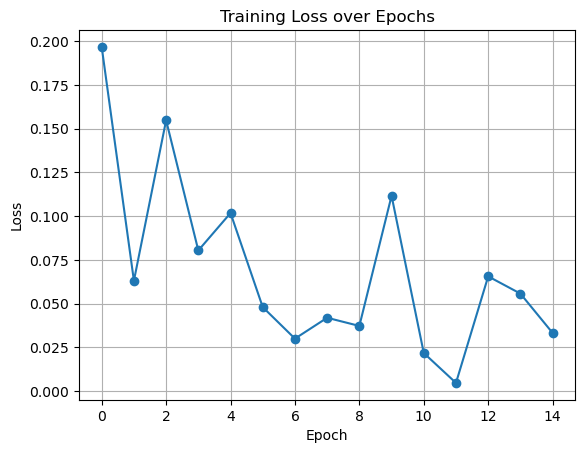

In [24]:
from scipy.interpolate import make_interp_spline

plt.plot(list(training_loss_history.keys()), list(training_loss_history.values()), marker='o')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.show()
    

## Final Project Conclusions

* **Performance Leap:** Mini-batch training dramatically improved model accuracy, jumping from ~89% to **~97.5%**.
* **Efficiency:** The network reached target accuracy in as few as 10 epochs.
* **Generalization:** Randomizing batches effectively acted as a regularization technique, preventing overfitting.
* **Hyperparameter Sensitivity:** While higher learning rates (e.g., `0.09`) accelerate convergence, they introduce instability and the risk of gradient explosion. Model success at these rates proved highly sensitive to the initial random seed (succeeding with seed `42`, but occasionally failing with others).
* **Instability in minibatch:** Mini-batch training shows instability when learning rate is high (0.09) 